In [1]:
from pathlib import Path
from furax.interfaces.toast.observation import ToastObservation
import matplotlib.pyplot as plt

## Loading the data from toast

In [2]:
filename = Path("tests/data/test_obs.h5")
if not filename.exists():
    raise FileNotFoundError(f"{filename} does not exist")

obs = ToastObservation.from_file(filename)

## Get the TOD, HWP angles

In [105]:
import numpy as np
from furax.math.quaternion import to_lonlat_angles

In [103]:
tod = obs.get_tods() # shape: (n_detectors, n_samples)
sample_mask = obs.get_sample_mask() # shape: (n_samples,)
scanning_mask = obs.get_scanning_mask()

azimuth = obs.get_azimuth() # shape: (n_samples,)
elevation = obs.get_elevation() # shape: (n_samples,)

hwp_angles = obs.get_hwp_angles() # shape: (n_samples,)
time = obs.get_elapsed_times() # shape: (n_samples,)

qfull = np.roll(obs._get_expanded_quats(), 1, axis=-1) # shape: (n_detectors, n_samples, 4) # quarternions

In [104]:
scanning_mask

Array([ True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False,

In [94]:
lon, lat, _ = to_lonlat_angles(qfull) # convert the quarternions to lon, lat
lon_, lat_ = obs.get_detector_pointing_lonlat(thin_samples=10, use_scanning_mask=False, use_degrees=False) # get the detector lon, lat

In [95]:
colors = ["violet", "orange"]

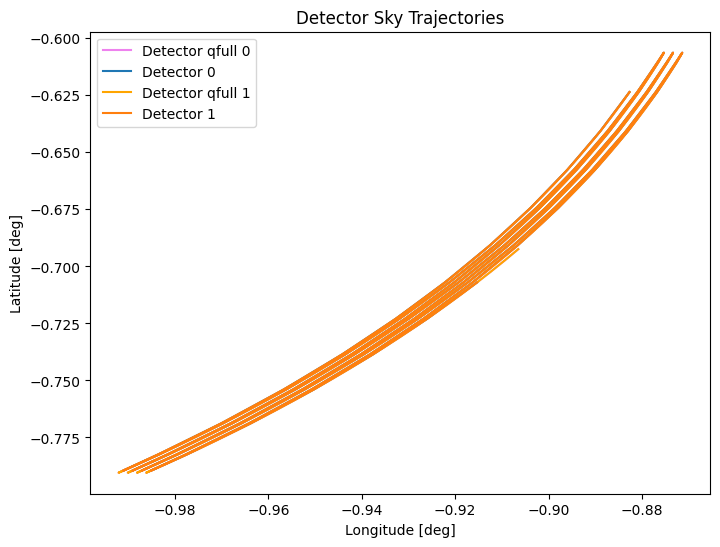

In [96]:
n_detectors = lon.shape[0]

plt.figure(figsize=(8, 6))
for i in range(n_detectors):
    plt.plot(lon[i, :], lat[i, :], color=colors[i], label=f'Detector qfull {i}')
    plt.plot(lon_[i, :], lat_[i, :], label=f'Detector {i}')

plt.xlabel("Longitude [deg]")
plt.ylabel("Latitude [deg]")
plt.title("Detector Sky Trajectories")
plt.legend()

# plt.xlim(lon.min(), lon.max())
# plt.ylim(lat.min(), lat.max())

plt.show()

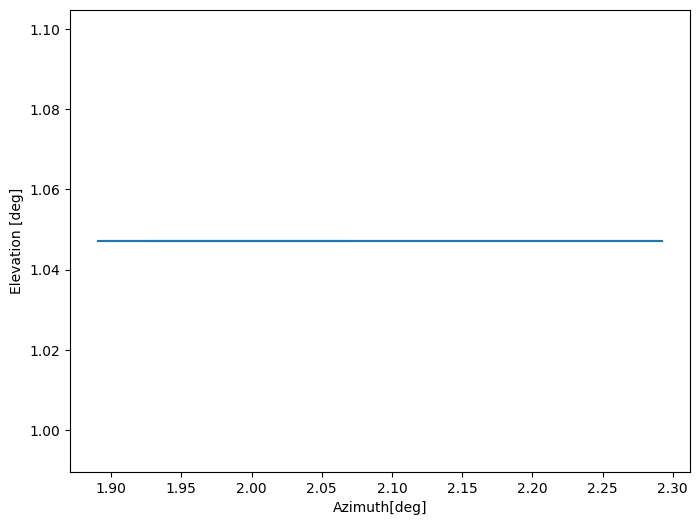

In [102]:
# Constant elevation scan
plt.figure(figsize=(8, 6))

plt.plot(azimuth, elevation)
plt.xlabel("Azimuth[deg]")
plt.ylabel("Elevation [deg]")
plt.show()

plt.close()

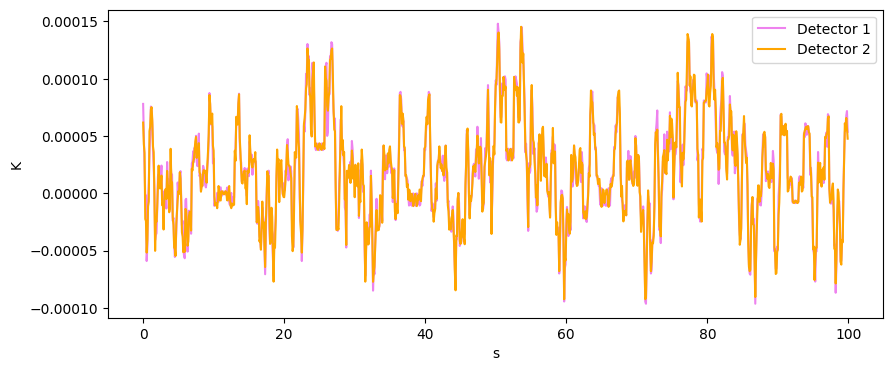

In [42]:
plt.figure(figsize=(10,4))
plt.plot(time, tod[0], color="violet", label="Detector 1")
plt.plot(time, tod[1], color="orange", label="Detector 2")

plt.xlabel("s")
plt.ylabel(r"K")
plt.legend()
plt.show()
plt.close()

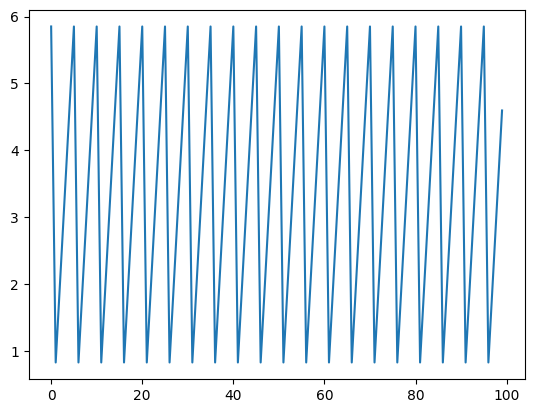

In [10]:
plt.figure()
plt.plot(hwp_angles[:100])

plt.show()
plt.close()

## Landscape info

In [15]:
from furax.obs.landscapes import HealpixLandscape

In [16]:
# Define sky resolution
nside = 512
landscape = HealpixLandscape(nside=nside, stokes='IQU')
n_pix = landscape.shape[0]

print(f"Sky map: {n_pix} pixels with {landscape.stokes} Stokes parameters")
print(f"Total sky parameters: {landscape.size}")

Sky map: 3145728 pixels with IQU Stokes parameters
Total sky parameters: 9437184


In [109]:
pointing, spin_angles = obs.get_pointing_and_spin_angles(landscape=landscape)

In [111]:
pointing.shape

(2, 1000)